# Simulator For TRPL Data

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import numpy as np
import matplotlib.pyplot as plt

### Oxford color scheme
base_color = "#002147"
color_scheme = ["#44687d", "#69913b", '#cf7a30', '#be0f34']
highlight_color = "#ac48bf"

line_type_list = ['-', '-.', '--', ':']

centimeters = 1/2.54
fontsize_base = 11
figure_width = 21


# Model

In [2]:
def total_recombination_rate_jax(dt_current, n_dens, p_dens, ds, params, S_f, S_b):
    # Unpack parameters
    _, _, _, _, D = params

    # a. Recombination (Runge-Kutta Algorithm)
    nt = p_dens - n_dens
    RuKu1_n, RuKu1_nt = rate_equations_jax(n_dens, nt, params)
    RuKu2_n, RuKu2_nt = rate_equations_jax(n_dens + RuKu1_n*dt_current/2, nt + RuKu1_nt*dt_current/2, params)
    RuKu3_n, RuKu3_nt = rate_equations_jax(n_dens + RuKu2_n*dt_current/2, nt + RuKu2_nt*dt_current/2, params)
    RuKu4_n, RuKu4_nt = rate_equations_jax(n_dens + RuKu3_n*dt_current, nt + RuKu3_nt*dt_current, params)

    Ruku_n = (RuKu1_n + 2*RuKu2_n + 2*RuKu3_n + RuKu4_n)/6
    Ruku_nt = (RuKu1_nt + 2*RuKu2_nt + 2*RuKu3_nt + RuKu4_nt)/6

    # b. Diffusion
    d_factor = D * dt_current / (2 * ds * ds)
    x_size = n_dens.shape[0]
    A_n = X_n_maker_jax(-d_factor, x_size, ds, D, S_f, S_b)
    B_n = X_n_maker_jax(d_factor, x_size, ds, D, S_f, S_b)

    Bn_dot_n_dens = jnp.dot(B_n, n_dens) + Ruku_n * dt_current
    n_dens_new = jnp.linalg.solve(A_n, Bn_dot_n_dens)

    # c. Physical limits
    n_dens_new = jnp.where(n_dens_new <= 0, 0, n_dens_new)
    p_dens_new = n_dens_new + nt + Ruku_nt * dt_current
    p_dens_new = jnp.where(p_dens_new <= 0, 0, p_dens_new)

    return n_dens_new, p_dens_new

def rate_equations_jax(n_dens, nt, params):
    k_c, k_deep, k_e, k_rad, _ = params
    p_dens = n_dens + nt
    R_rad = -k_rad * n_dens * p_dens
    dnt_dt = k_c * n_dens - k_e * nt
    R_nr = -k_c * n_dens + k_e * nt - k_deep * n_dens
    dn_dt = R_rad + R_nr
    return dn_dt, dnt_dt

def X_n_maker_jax(d_factor, x_size, dx, D, Sf, Sb):
    Xn = jnp.zeros((x_size, x_size))
    Xn = Xn.at[jnp.diag_indices(x_size)].set(1 - 2 * d_factor)
    Xn = Xn.at[(jnp.arange(1, x_size), jnp.arange(x_size - 1))].set(d_factor)
    Xn = Xn.at[(jnp.arange(x_size - 1), jnp.arange(1, x_size))].set(d_factor)
    Xn = Xn.at[0, 0].set(1 - d_factor - (dx / D) * d_factor * Sf)
    Xn = Xn.at[-1, -1].set(1 - d_factor - (dx / D) * d_factor * Sb)
    return Xn

In [3]:
def model_in_jax(params, time, constants):
    # Unpack parameters
    mu_vert, k_rad, k_deep, k_c, k_e, S1, S2 = params
    Thickness, Fluences, alphas, Svals = constants

    # Convert all arrays to jax.numpy arrays
    time = jnp.array(time)
    Fluences = jnp.array(Fluences)
    alphas = jnp.array(alphas)
    Svals = jnp.array(Svals)

    p0 = 0.0

    S_front_val = jnp.where(Svals == 1, S1, S2)
    S_back_val = jnp.where(Svals == 1, S2, S1)

    z_array = jnp.linspace(0, Thickness, 30)
    time_fit = time * 1e-9
    dt = jnp.diff(time_fit)
    ds = z_array[1] - z_array[0]

    # Diffusion coefficient
    limit_mobility = (Thickness) ** 2 / (dt[0]) / (1.380649e-23 * 292 / 1.6021766e-19)
    Diffusion_coefficient = mu_vert * (1.380649e-23 * 292 / 1.6021766e-19)

    params_iter = (k_c, k_deep, k_e, k_rad, Diffusion_coefficient)

    alphas = jnp.where(mu_vert >= limit_mobility / 4, 0, alphas)

    generation = jnp.exp(-jnp.outer(z_array, alphas))
    generation_sum = jnp.sum((generation[1:] + generation[:-1]) / 2, axis=0) * ds
    n_0z = Fluences / generation_sum * generation

    N_calc = jnp.zeros((len(time_fit), len(z_array), len(Fluences)))
    P_calc = jnp.zeros((len(time_fit), len(z_array), len(Fluences)))

    N_calc = N_calc.at[0, :, :].set(n_0z)
    P_calc = P_calc.at[0, :, :].set(n_0z + p0)

    def time_step(carry, t):
        N, P = carry
        N_new = N.copy()
        P_new = P.copy()
        for f in range(len(Fluences)):
            Sf = S_front_val[f]
            Sb = S_back_val[f]
            n_dens, p_dens = total_recombination_rate_jax(dt[t], N[t, :, f], P[t, :, f], ds, params_iter, Sf, Sb)
            N_new = N_new.at[t+1, :, f].set(n_dens)
            P_new = P_new.at[t+1, :, f].set(p_dens)
        return (N_new, P_new), None

    # Run the time steps
    (N_calc, P_calc), _ = jax.lax.scan(time_step, (N_calc, P_calc), jnp.arange(len(dt)))

    Rrad_calc = N_calc * P_calc
    PL_calc = jnp.sum((Rrad_calc[:, 1:, :] + Rrad_calc[:, :-1, :]) / 2, axis=1) * ds
    PL_0 = PL_calc[0, :]
    PL_obs = PL_calc / PL_0

    return PL_obs

## Main Part

In [4]:
import time as time_step
# Parameter Definition (JAX-compatible)
Fluences = jnp.array([4.8e9, 4.8e10, 4.8e11])   # photons cm-2
alphas = jnp.array([3e5, 3e5, 3e5])  # cm-1
Thickness = 600e-7   # cm
Svals = jnp.array([1, 1, 1])

constants = (Thickness, Fluences, alphas, Svals)

time = jnp.append(0, jnp.logspace(-1, 3, 500))  # ns

# mu_vert, k_rad, k_deep, k_c, k_e, S1, S2
true_vals = (1.0, 1e-10, 1e6, 1.0, 1.0, 10.0, 100.0)
params = true_vals

start = time_step.time()
PL = model_in_jax(params, time, constants)
stop = time_step.time()

sim_dat = PL + (-jax.random.uniform(jax.random.PRNGKey(0), shape=PL.shape) * 0.1 + 0.05)
sim_dat = sim_dat / sim_dat[0, :]

print(stop-start)

1.9225268363952637


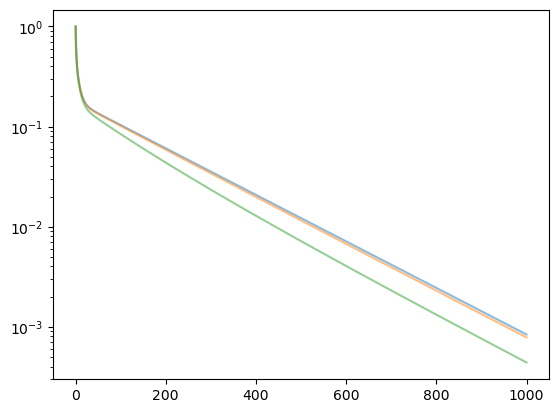

In [5]:
plt.plot(time, PL, alpha=0.5)
plt.yscale('log')

In [ ]:
def numpyro_trpl_model(time, y_obs, constants):
    # Priors (log-uniform for positive parameters)
    mu_vert = numpyro.sample('mu_vert', dist.LogUniform(1e-2, 10))
    k_rad = numpyro.sample('k_rad', dist.LogUniform(1e-12, 1e-8))
    k_deep = numpyro.sample('k_deep', dist.LogUniform(1e3, 1e7))
    k_c = numpyro.sample('k_c', dist.LogUniform(1, 1e7))
    k_e = numpyro.sample('k_e', dist.LogUniform(1, 1e7))
    S1 = numpyro.sample('S1', dist.LogUniform(1, 1e5))
    S2 = numpyro.sample('S2', dist.LogUniform(1, 1e5))
    
    params = (mu_vert, k_rad, k_deep, k_c, k_e, S1, S2)
    y_model = model_in_jax(params, time, constants)
    
    # Likelihood
    sigma = numpyro.sample('sigma', dist.HalfNormal(0.1))
    numpyro.sample('obs', dist.Normal(y_model, PL), obs=y_obs)

# Prepare data
y_obs = sim_dat  # or your observed data
rng_key = jax.random.PRNGKey(0)

# Run MCMC
kernel = NUTS(numpyro_trpl_model)
mcmc = MCMC(kernel, num_warmup=500, num_samples=500)
mcmc.run(rng_key, time, y_obs, constants)
posterior_samples = mcmc.get_samples()

warmup:   3%|▎         | 28/1000 [01:04<34:49,  2.15s/it, 9 steps of size 1.08e-02. acc. prob=0.71]   

niter: 450
ncall: 1908
nsamples: 470
logz: -18392.699 +/-  0.988
h: 19.532
[9.57481007e-02 5.95250139e-11 2.89693514e+03 9.56260158e+06
 1.32869460e+05 1.28906202e+02 1.10807946e+00]


C:\Users\kcm\AppData\Local\Temp\ipykernel_23724\3537918652.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


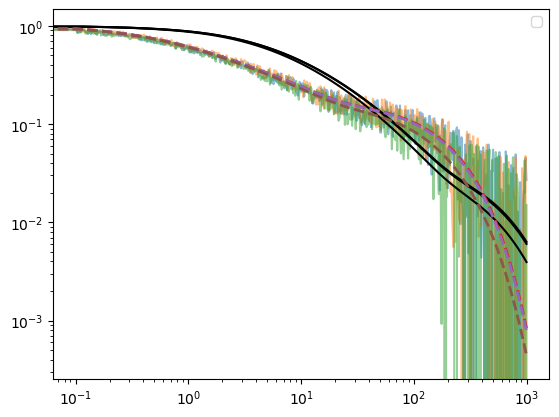

In [ ]:
param_labels = ['mu_vert', 'k_rad', 'k_deep', 'k_c', 'k_e', 'S1', 'S2']

p, cov = nestle.mean_and_cov(res.samples, res.weights)

y_res_mean, _ , _ = model_in_pytensor(p, time, constants)

print(res.summary())

print(p)

plt.plot(time, sim_dat, alpha=0.5)
plt.plot(time, y_res_mean, c='k')
plt.plot(time, PL, linewidth=2, linestyle='--')

plt.xscale('log')
plt.yscale('log')
plt.legend()

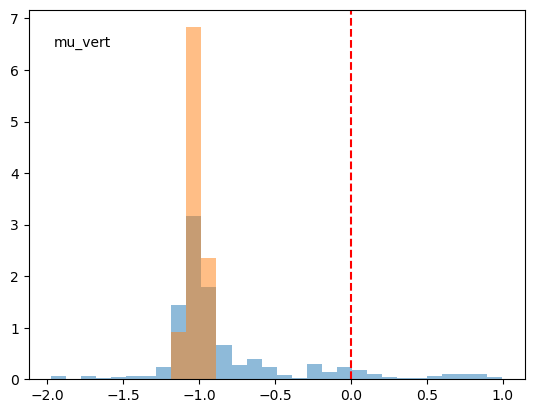

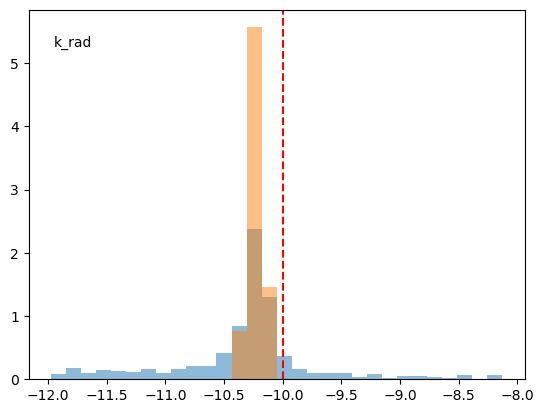

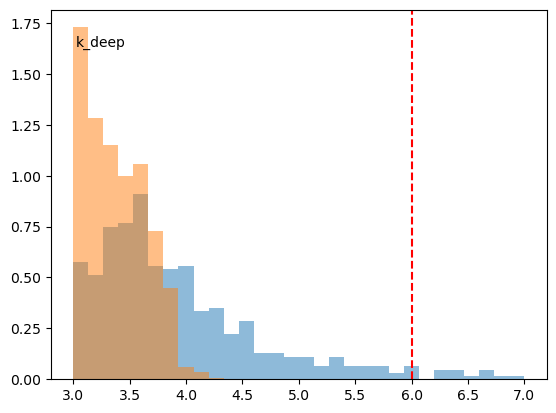

C:\Users\kcm\AppData\Local\Temp\ipykernel_23724\2411076039.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.axvline(np.log10(true_vals[i]), 0, 100, c='red', linestyle='--')


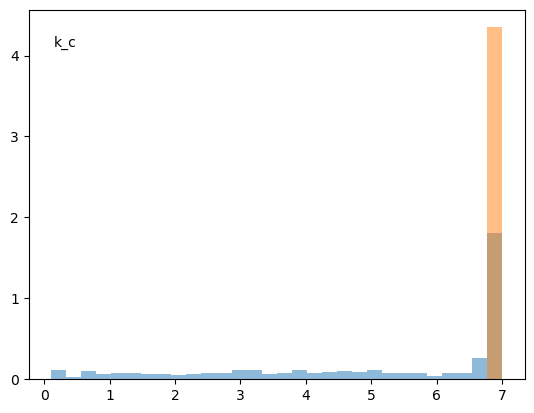

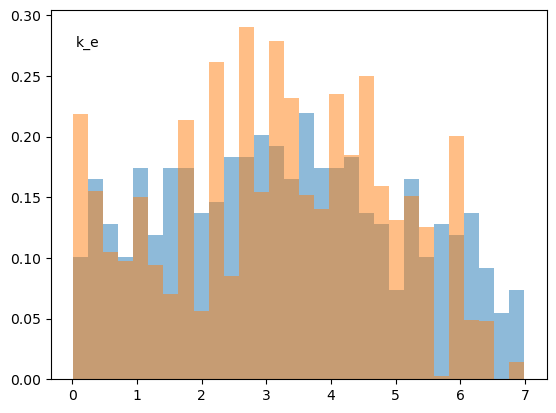

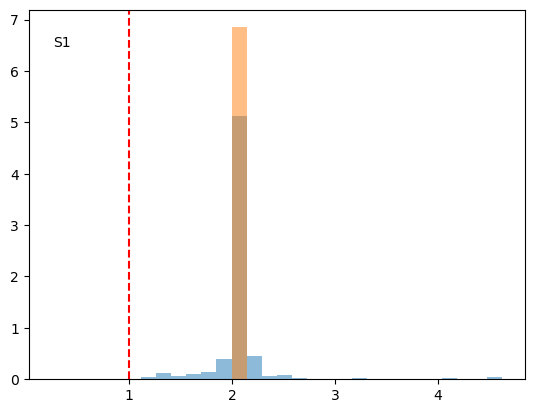

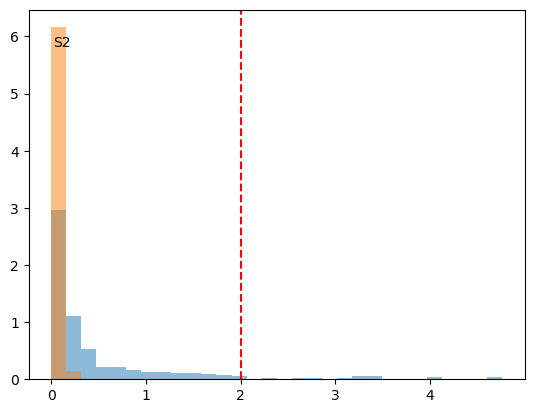

In [741]:
param_labels = ['mu_vert', 'k_rad', 'k_deep', 'k_c', 'k_e', 'S1', 'S2']

for i, p_val in enumerate(p):
    plt.axvline(np.log10(true_vals[i]), 0, 100, c='red', linestyle='--')
    plt.annotate(param_labels[i], [0.05, 0.9], xycoords='axes fraction')
    plt.hist(np.log10(res.samples[:,i]), bins=30, density = True, alpha=0.5)
    plt.hist(np.log10(res.samples[:,i]),weights=res.weights, bins=30, density = True, alpha=0.5)
    plt.show()

## VI

In [ ]:
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal
import optax

start = time_step.time()

def numpyro_trpl_model(time, y_obs, constants):
    # Priors (log-uniform for positive parameters)
    mu_vert = numpyro.sample('mu_vert', dist.LogUniform(1e-2, 10))
    k_rad = numpyro.sample('k_rad', dist.LogUniform(1e-12, 1e-8))
    k_deep = numpyro.sample('k_deep', dist.LogUniform(1e3, 1e7))
    k_c = numpyro.sample('k_c', dist.LogUniform(1, 1e7))
    k_e = numpyro.sample('k_e', dist.LogUniform(1, 1e7))
    S1 = numpyro.sample('S1', dist.LogUniform(1, 1e5))
    S2 = numpyro.sample('S2', dist.LogUniform(1, 1e5))
    
    params = (mu_vert, k_rad, k_deep, k_c, k_e, S1, S2)
    y_model = model_in_jax(params, time, constants)
    
    # Likelihood
    sigma = numpyro.sample('sigma', dist.HalfNormal(0.1))
    numpyro.sample('obs', dist.Normal(y_model, PL), obs=y_obs)


# Prepare data
y_obs = sim_dat  # or your observed data
rng_key = jax.random.PRNGKey(0)

# Define the guide (variational family)
guide = AutoNormal(numpyro_trpl_model)

# Set up the optimizer
optimizer = optax.adam(1e-2)

# Set up SVI
svi = SVI(numpyro_trpl_model, guide, optimizer, loss=Trace_ELBO())

# Run SVI
svi_state = svi.init(rng_key, time, y_obs, constants)
num_steps = 2000

for step in range(num_steps):
    svi_state, loss = svi.update(svi_state, time, y_obs, constants)
    if step % 50 == 0:
        timestep = time_step.time()
        print(f"Step {step}, loss: {loss}, time: {np.round(timestep-start,0)} s")

# Get posterior samples
params = svi.get_params(svi_state)
posterior_samples = guide.sample_posterior(rng_key, params, sample_shape=(1000,), 
                                           time=time, y_obs=y_obs, constants=constants)

Step 1758277970.5142174, loss: 29924.337890625, time: 13.897355794906616 s


KeyboardInterrupt: 